### All of Statistics | Larry Wasserman | Solutions and Code by David A. Lee
### Chapter 8: The Bootstrap

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.stats import skew 
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig
from scipy.stats import pearsonr

SEED = 2024   # each cell starts its own generator from this, so every figure is reproducible on its own

1. Consider the data in Example 8.6. Find the plug-in estimate of the correlation coefficient. Estimate the standard error using the boostrap. Find a 95 percent confidence interval using the Normal, pivotal, and percentile methods.

Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap8ex1i.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap8\chap8ex1i.eps


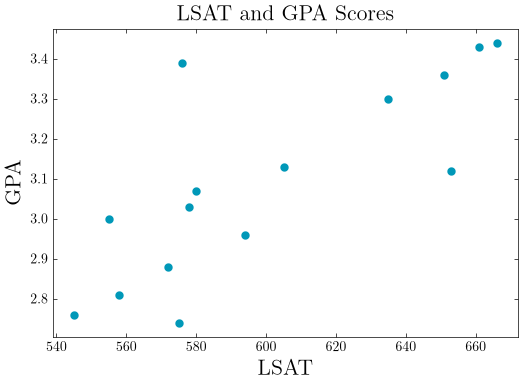

In [2]:
LSAT = [576, 635, 558, 578, 666, 580, 555, 661, 651, 605, 653, 575, 545, 572, 594]
GPA = [3.39, 3.30, 2.81, 3.03, 3.44, 3.07, 3.00, 3.43, 3.36, 3.13, 3.12, 2.74, 2.76, 2.88, 2.96]

plt.figure(figsize=(6,4))
plt.scatter(LSAT, GPA, marker='.', color=C.cyan, linewidths=3)
plt.title('LSAT and GPA Scores', fontsize=16)
plt.xlabel('LSAT', fontsize=16)
plt.ylabel('GPA', fontsize=16)
plt.minorticks_off()
savefig(plt.gcf(), 'chap8ex1i.eps', bbox_inches=None)
plt.show()

In [3]:
rng = np.random.default_rng(SEED)
est = pearsonr(LSAT, GPA)[0]

b = len(LSAT)
B = 1000

def bootstrap():
    # B resamples of the b (LSAT, GPA) pairs -- VERY IMPORTANT! Sample WITH REPLACEMENT from the dataset.
    idx = rng.integers(0, b, size=(B, b))
    L, G = np.array(LSAT)[idx], np.array(GPA)[idx]
    L, G = L - L.mean(axis=1, keepdims=True), G - G.mean(axis=1, keepdims=True)
    return (L*G).sum(axis=1)/np.sqrt((L*L).sum(axis=1)*(G*G).sum(axis=1))   # Pearson correlation of each resample

sampleboot = bootstrap()

seboot = np.std(sampleboot)

# alpha = 0.05
normci = (est - 1.96*seboot, est + 1.96*seboot)
pivotalci = (2*est - np.quantile(sampleboot, 0.975), 2*est - np.quantile(sampleboot, 0.025))
percentileci = (np.quantile(sampleboot, 0.025), np.quantile(sampleboot, 0.975))

print("%.4f" % est, "%.4f" % seboot, "(%.4f,%.4f)" % normci, "(%.4f,%.4f)" % pivotalci, "(%.4f,%.4f)" % percentileci)


0.7764 0.1263 (0.5287,1.0240) (0.5902,1.0879) (0.4649,0.9625)


<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\w'
<>:4: SyntaxWarning: invalid escape sequence '\w'
C:\Users\david\AppData\Local\Temp\ipykernel_40316\1391137851.py:3: SyntaxWarning: invalid escape sequence '\w'
  plt.title('$\widehat{\\rho}^{*}$ Bootstrap Distribution', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_40316\1391137851.py:4: SyntaxWarning: invalid escape sequence '\w'
  plt.xlabel('$\widehat{\\rho}^{*}$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap8ex1ii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap8\chap8ex1ii.eps


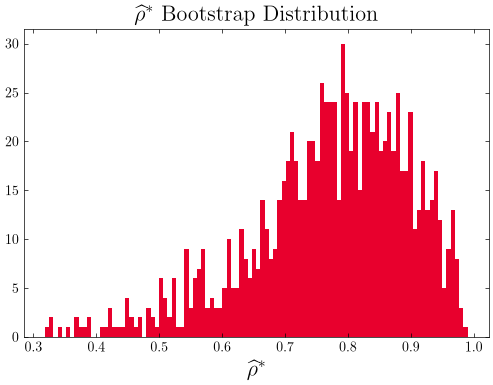

In [4]:
plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(sampleboot, bins=100, color=C.red)
plt.title('$\widehat{\\rho}^{*}$ Bootstrap Distribution', fontsize=16)
plt.xlabel('$\widehat{\\rho}^{*}$', fontsize=16)
plt.minorticks_off()
savefig(plt.gcf(), 'chap8ex1ii.eps', bbox_inches=None)
plt.show()


2. (Computer Experiment.) Conduct a simulation to compare the various bootstrap confidence interval methods. Let $n = 50$ and let $T(F) = \int (x - \mu)^3 dF(x) / \sigma^3$ be the skewness. Draw $Y_1, \dots, Y_n \sim N(0,1)$ and set $X_i = e^{Y_i}, i = 1, \dots, n$. Construct the three types of bootstrap 95 percent intervals for $T(F)$ from the data $X_1, \dots, X_n$. Repeat this whole thing many times and estimate the true coverage of the three intervals.

Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap8ex2expnormal.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap8\chap8ex2expnormal.eps


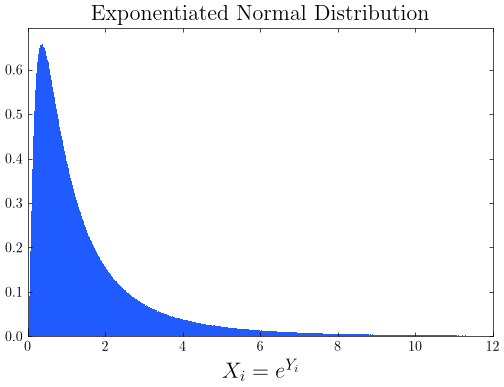

In [5]:
rng = np.random.default_rng(SEED)
y = rng.normal(0,1,int(1e8))
x = np.exp(y)
trueskew = skew(x)
trueskew

plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(x, bins=100000, density=True, color=C.blue)
plt.title('Exponentiated Normal Distribution', fontsize=16)
plt.xlabel("$X_{i} = e^{Y_{i}}$", fontsize=16)
plt.xlim(0, 12)
plt.minorticks_off()
savefig(plt.gcf(), 'chap8ex2expnormal.eps', bbox_inches=None)
plt.show()

3. Let

$$X_1 , \cdots , X_n ∼ t_3$$

where $n = 25$. Let $\theta = T(F) = (q_{.75} − q{.25} ) /1.34$ where $q_p$ denotes the $p^{th}$ quantile. Do a simulation to compare the coverage and length of the
following confidence intervals for $\theta$:

(i) Normal interval with standard error from the bootstrap,

(ii) bootstrap percentile interval, and

(iii) pivotal bootstrap interval.

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
C:\Users\david\AppData\Local\Temp\ipykernel_40316\1574061514.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Distribution of $X \sim t_3$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap8ex3tdistribution.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap8\chap8ex3tdistribution.eps


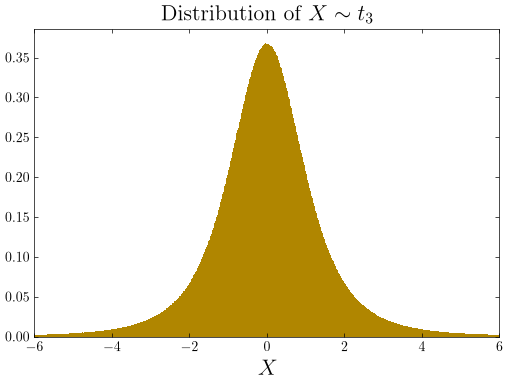

In [6]:
N = int(1e8)
rng = np.random.default_rng(SEED)
tpoints = rng.standard_t(3, N)

plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(tpoints, bins=100000, density=True, color=C.yellow)
plt.title('Distribution of $X \sim t_3$', fontsize=16)
plt.xlabel("$X$", fontsize=16)
plt.xlim(-6, 6)
plt.minorticks_off()
savefig(plt.gcf(), 'chap8ex3tdistribution.eps', bbox_inches=None)
plt.show()
